In [ ]:
#Evalution and Performance Metrics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel("EastWestAirlines.xlsx", sheet_name="data")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [3]:
df.shape

(3999, 12)

In [4]:
df.size

47988

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [6]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop(columns=["ID#","Award?"],inplace=True)

#We are droping ID and Award because 
# ID# is simply customer identifier It doesn't describe customer behavior, so we should not use it for clustering.
#Award this represent wheather the customer recieves an award or not Because this is a target-like/business outcome rather than a customer behavior feature, we generally exclude it from the clustering features.

In [9]:
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
0,28143,0,1,1,1,174,1,0,0,7000
1,19244,0,1,1,1,215,2,0,0,6968
2,41354,0,1,1,1,4123,4,0,0,7034
3,14776,0,1,1,1,500,1,0,0,6952
4,97752,0,4,1,1,43300,26,2077,4,6935


In [10]:
df.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
count,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000
mean,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939
std,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454
min,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000
25%,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000
50%,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000
75%,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000
max,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000


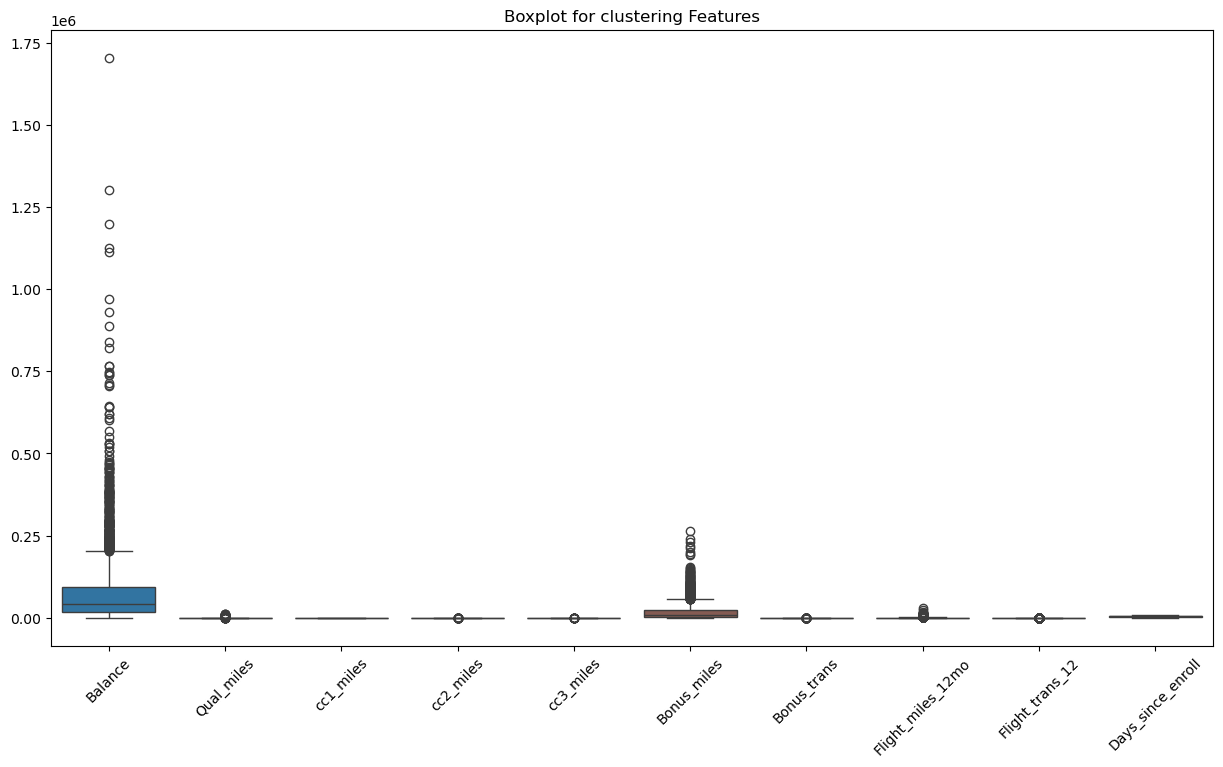

In [11]:
#Outlier Detection
plt.figure(figsize=(15,8))
sns.boxplot(df)
plt.xticks(rotation=45)
plt.title("Boxplot for clustering Features")
plt.show()

In [ ]:
# For an airline customer dataset, a customer with a very high balance or many flight miles could be a genuine high-value/frequent traveler, not a data error.If we remove every IQR outlier, we might remove exactly the customers we want clustering to discover.

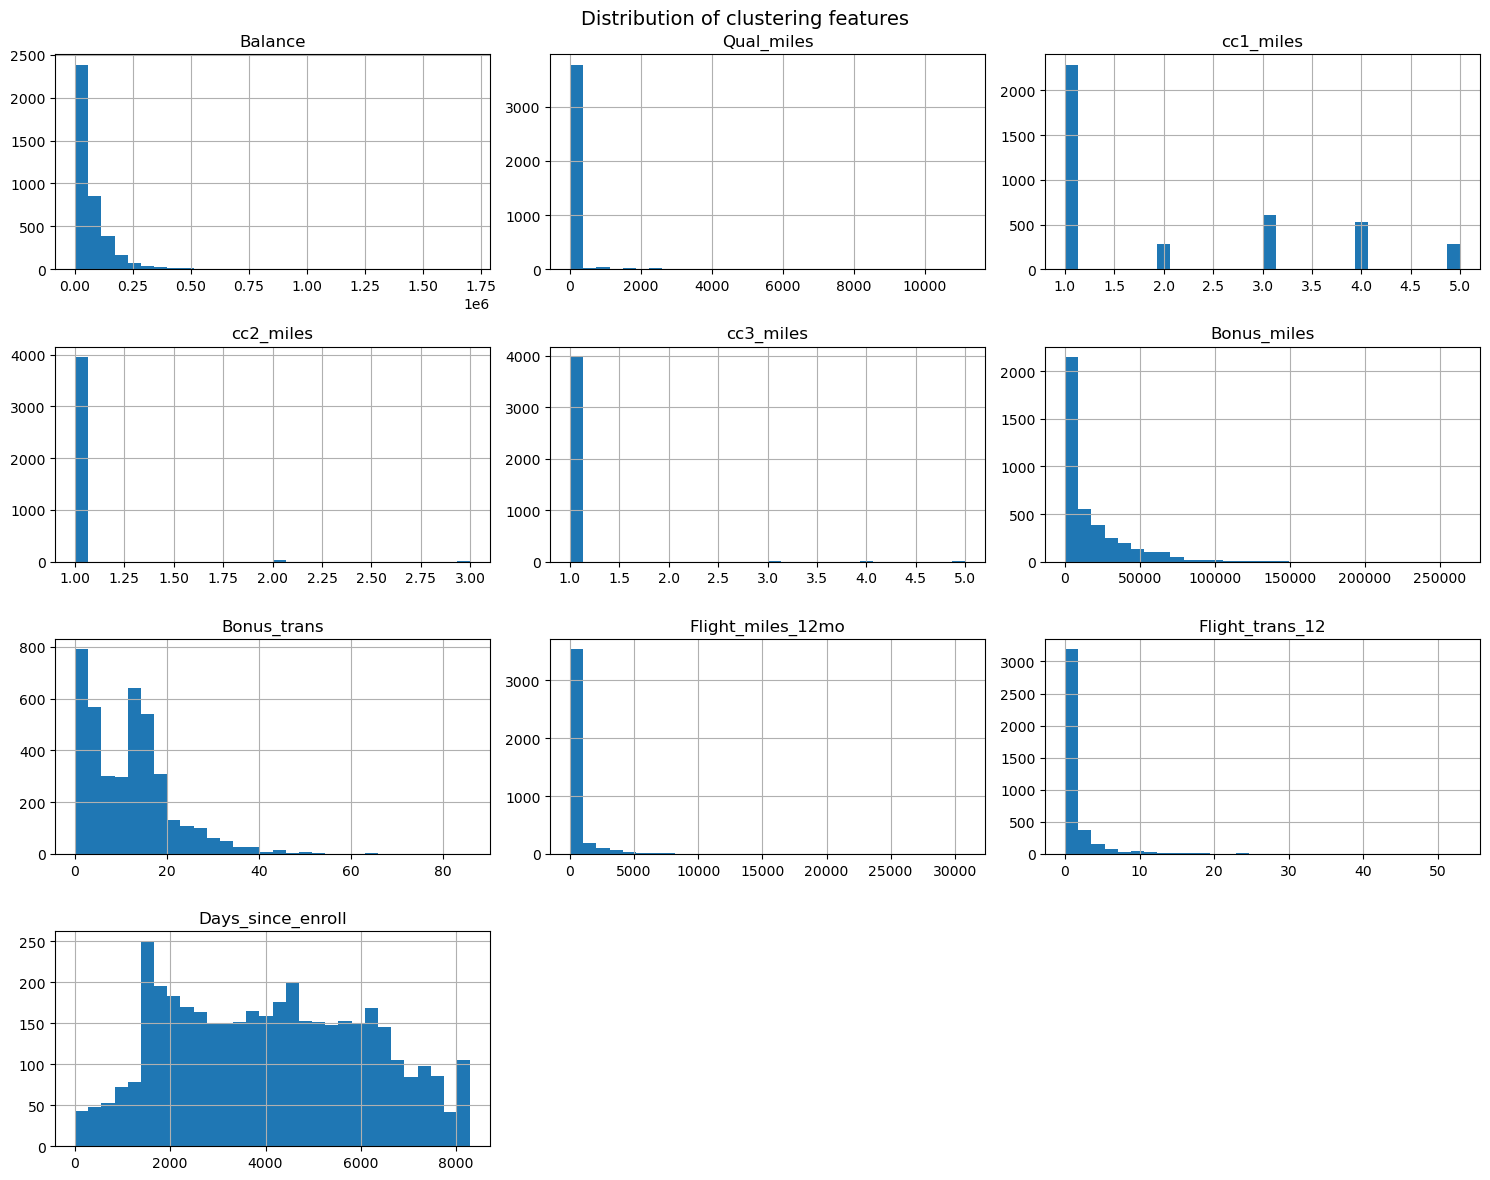

In [12]:
#EDA
df.hist(figsize=(15,12),bins=30)
plt.suptitle("Distribution of clustering features", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Histograms help us understand:

# whether variables are normally distributed whether they are right/left skewed whether there are unusual values where most customers are concentrated

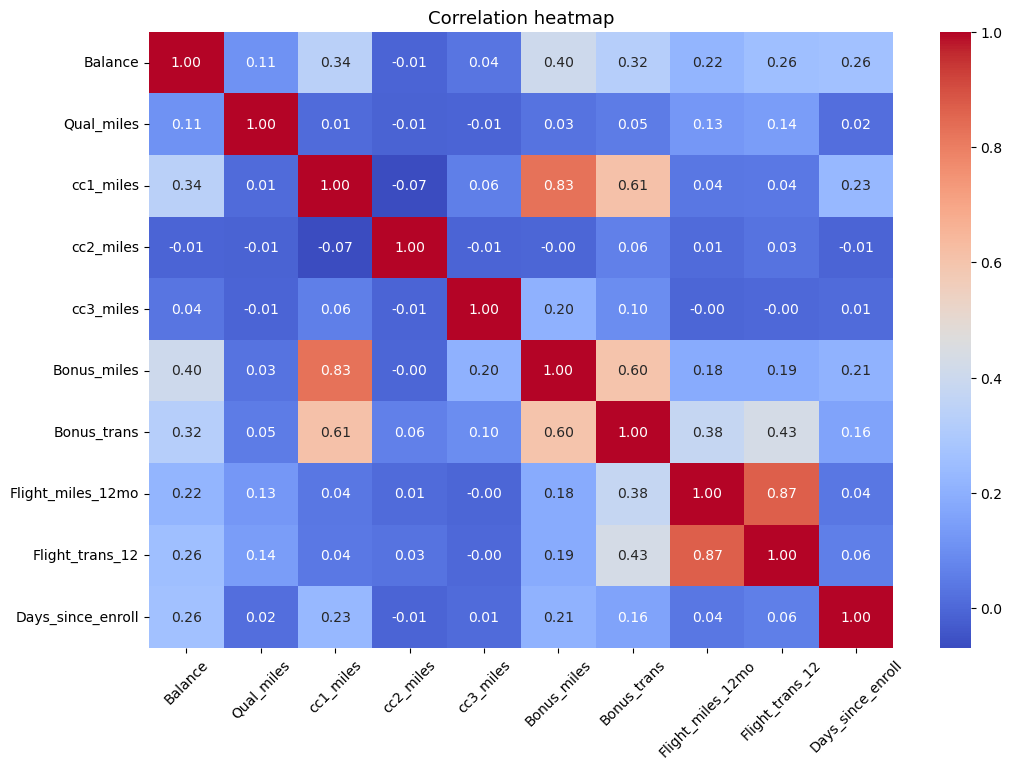

In [13]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation heatmap",fontsize=13)
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Correlation Analysis: The heatmap shows strong positive correlations between cc1_miles and Bonus_miles (0.83), and between Flight_miles_12mo and Flight_trans_12 (0.87). This indicates that credit-card mileage category is strongly associated with bonus miles, while recent flight miles are strongly associated with flight transactions. These relationships may contribute to the formation of meaningful customer segments.

In [14]:
#Scaling
x=df.copy()
print(x.shape)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
sc_scaled=sc.fit_transform(x)
print(sc_scaled.shape)

#"Learn the mean and standard deviation from , and then immediately scale X using those values."

(3999, 10)
(3999, 10)


In [15]:
#checking mean and standared deviation
sc_scaled = pd.DataFrame(sc_scaled,columns=df.columns)
sc_scaled.describe().round(2)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
count,3999.00,3999.00,3999.00,3999.00,3999.00,3999.00,3999.00,3999.00,3999.00,3999.00
mean,0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.73,-0.19,-0.77,-0.10,-0.06,-0.71,-1.21,-0.33,-0.36,-1.99
25%,-0.55,-0.19,-0.77,-0.10,-0.06,-0.66,-0.90,-0.33,-0.36,-0.87
50%,-0.30,-0.19,-0.77,-0.10,-0.06,-0.41,0.04,-0.33,-0.36,-0.01
75%,0.19,-0.19,0.68,-0.10,-0.06,0.28,0.56,-0.11,-0.10,0.81
max,16.19,14.22,2.14,13.45,20.43,10.21,7.75,21.68,13.61,2.02


In [16]:
#Elbow method
#Calculating inertia for different K values
from sklearn.cluster import KMeans
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(sc_scaled)
    inertia.append(kmeans.inertia_)

print(inertia)
print("Number of values:", len(inertia))

[32088.27969959077, 27558.68727688437, 23807.81421245637, 20349.101443769952, 18475.01687360302, 16956.233801938488, 14349.755207343624, 13228.038941278397, 12154.151957114587]
Number of values: 9


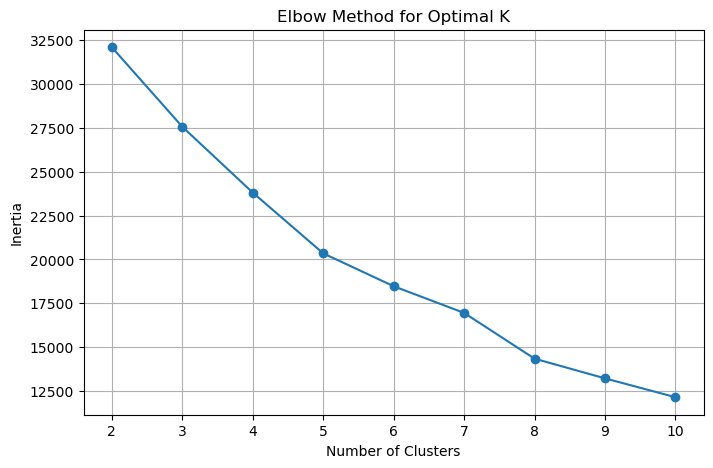

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)

plt.show()

In [18]:
#Calculate using Silhouette Score for k=2 to 10
#Silhouette Score menas It measures how well each data point fits within its own cluster compared with other clusters.
from sklearn.metrics import silhouette_score
silhouette_scores=[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    labels=kmeans.fit_predict(sc_scaled)
    score = silhouette_score(sc_scaled, labels)
    silhouette_scores.append(score)
print(silhouette_score)

<function silhouette_score at 0x000001EF9F925260>


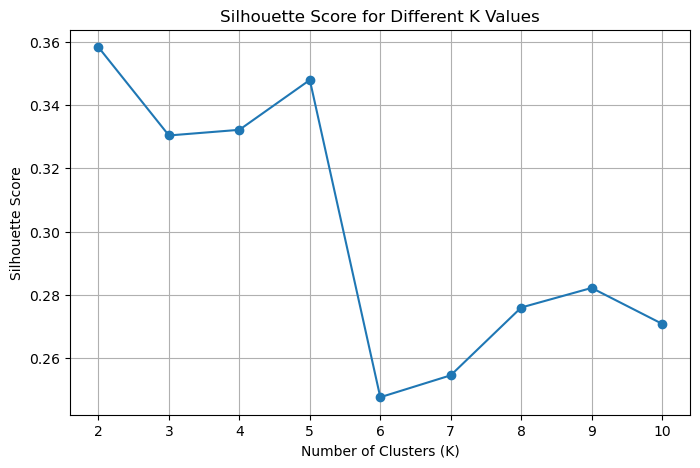

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

In [ ]:
# "The Elbow Method indicated a possible elbow around K=5, while the Silhouette Analysis produced the highest score of approximately 0.358 at K=2. Since the Elbow curve did not show a very distinct elbow, K=2 was selected based on the highest Silhouette Score. However, alternative values such as K=5 may also be explored for more detailed customer segmentation."

In [20]:
#final K-Means Model

final_Kmeans = KMeans(n_clusters=2,random_state=42,n_init=10)
kmeans_labels = final_Kmeans.fit_predict(sc_scaled)

In [21]:
#Checking cluster counts
pd.Series(kmeans_labels).value_counts().sort_index()

0    2793
1    1206
Name: count, dtype: int64

In [22]:
#Final Silhouette score
final_silhouette = silhouette_score(sc_scaled,kmeans_labels)
print("Final silhouette score :",final_silhouette)

Final silhouette score : 0.35826638416515033


In [23]:
#ADDing cluster labels to our original data
clustered_df=df.copy()
clustered_df["Cluster"] = kmeans_labels
clustered_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Cluster
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [24]:
#Analysing the clusters
cluster_profile = clustered_df.groupby("Cluster").mean()
cluster_profile.round(2)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
Cluster,,,,,,,,,,
0,44300.63,93.08,1.35,1.02,1.00,5760.48,7.64,223.76,0.66,3729.28
1,141459.42,262.31,3.71,1.01,1.04,43510.13,20.79,1007.30,3.02,5020.09


In [ ]:
# Analysis: K-Means identified two distinct customer segments. Cluster 0 consists primarily of relatively low-engagement customers with lower balances, fewer bonus miles, and lower flight activity. Cluster 1 represents high-value, highly engaged customers characterized by higher balances, greater flight and transaction activity, substantially higher bonus miles, and stronger credit-card mileage status. These clusters can help the airline differentiate between lower-engagement and high-value customers for targeted loyalty and marketing strategies.

In [25]:
#visualizing the Clusters
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
x_pca=pca.fit_transform(sc_scaled)
print(x_pca.shape)

(3999, 2)


In [26]:
pca_df=pd.DataFrame(x_pca,columns=["PC1","PC2"])
pca_df["Cluster"] = kmeans_labels
print(pca_df.head())

        PC1       PC2  Cluster
0 -1.302598 -0.066721        0
1 -1.286259 -0.063392        0
2 -1.032522 -0.136881        0
3 -1.346209 -0.060299        0
4  2.729014 -0.188741        1


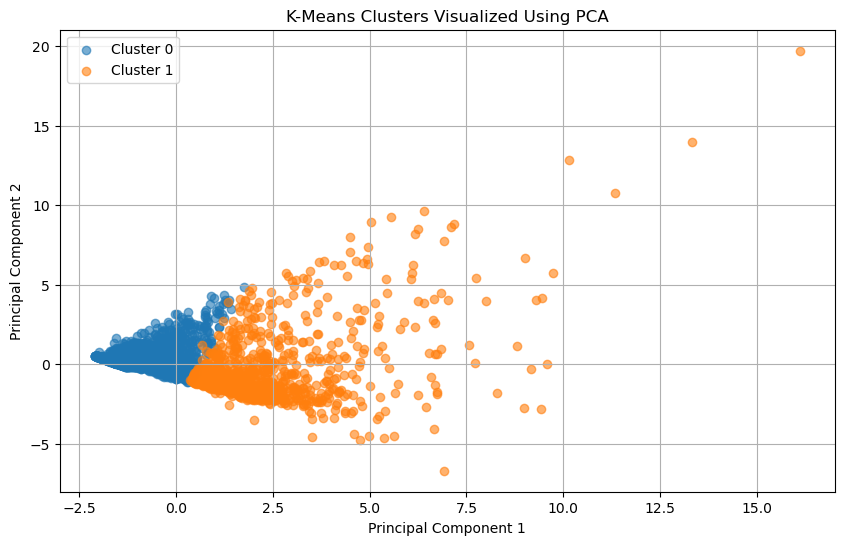

In [27]:
#Visualize clusters
plt.figure(figsize=(10, 6))

for cluster in sorted(pca_df["Cluster"].unique()):
    
    cluster_data = pca_df[pca_df["Cluster"] == cluster]
    
    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized Using PCA")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# PCA was used to reduce the 10-dimensional feature space to two principal components for visualization. The scatter plot shows that Cluster 0 is concentrated mainly in the lower PC1 region, while Cluster 1 is distributed across a wider range of PC1 values. Although there is some overlap between the clusters, a visible separation can be observed, supporting the presence of two distinct customer segments.

In [28]:
#DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5,min_samples=5)
dbscan_labels = dbscan.fit_predict(sc_scaled)

In [29]:
import numpy as np

unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

print(dict(zip(unique_labels, counts)))

{np.int64(-1): np.int64(1229), np.int64(0): np.int64(1796), np.int64(1): np.int64(177), np.int64(2): np.int64(40), np.int64(3): np.int64(7), np.int64(4): np.int64(272), np.int64(5): np.int64(436), np.int64(6): np.int64(5), np.int64(7): np.int64(5), np.int64(8): np.int64(4), np.int64(9): np.int64(10), np.int64(10): np.int64(7), np.int64(11): np.int64(5), np.int64(12): np.int64(6)}


In [30]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(sc_scaled)

distances, indices = neighbors.kneighbors(sc_scaled)

# Distance to the 5th nearest neighbor
k_distances = distances[:, min_samples - 1]

# Sort distances
k_distances = np.sort(k_distances)

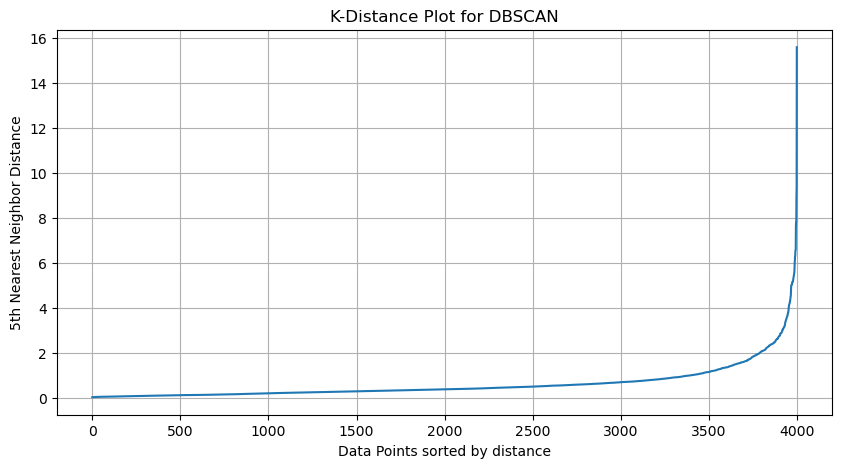

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.xlabel("Data Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN")
plt.grid(True)

plt.show()

In [32]:
from sklearn.cluster import DBSCAN
import numpy as np

eps_values = [1.5, 2.0, 2.5, 3.0, 3.5]

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(sc_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(
        f"eps={eps}: "
        f"Clusters={n_clusters}, "
        f"Noise={n_noise}"
    )

eps=1.5: Clusters=4, Noise=257
eps=2.0: Clusters=4, Noise=146
eps=2.5: Clusters=3, Noise=86
eps=3.0: Clusters=3, Noise=58
eps=3.5: Clusters=4, Noise=41


In [33]:
from sklearn.metrics import silhouette_score

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(sc_scaled)

    # Remove noise points
    mask = labels != -1

    X_clustered = sc_scaled[mask]
    labels_clustered = labels[mask]

    n_clusters = len(set(labels_clustered))

    if n_clusters >= 2:
        score = silhouette_score(
            X_clustered,
            labels_clustered
        )

        print(
            f"eps={eps}: "
            f"Clusters={n_clusters}, "
            f"Noise={np.sum(labels == -1)}, "
            f"Silhouette={score:.4f}"
        )
    else:
        print(
            f"eps={eps}: "
            f"Not enough clusters for Silhouette Score"
        )

eps=1.5: Clusters=4, Noise=257, Silhouette=0.6255
eps=2.0: Clusters=4, Noise=146, Silhouette=0.5925
eps=2.5: Clusters=3, Noise=86, Silhouette=0.5939
eps=3.0: Clusters=3, Noise=58, Silhouette=0.5873
eps=3.5: Clusters=4, Noise=41, Silhouette=0.5849


In [34]:
#Building Final DBSCAN model
final_dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)
dbscan_labels = final_dbscan.fit_predict(sc_scaled)

In [35]:
#checking cluster distribution
unique_labels, counts = np.unique(
    dbscan_labels,
    return_counts=True
)

print(dict(zip(unique_labels, counts)))

{np.int64(-1): np.int64(257), np.int64(0): np.int64(3705), np.int64(1): np.int64(22), np.int64(2): np.int64(10), np.int64(3): np.int64(5)}


In [36]:
#final DBSCAN silhouette score
mask = dbscan_labels != -1

X_dbscan = sc_scaled[mask]
labels_dbscan = dbscan_labels[mask]

final_dbscan_silhouette = silhouette_score(
    X_dbscan,
    labels_dbscan
)

print(
    "Final DBSCAN Silhouette Score:",
    final_dbscan_silhouette
)

Final DBSCAN Silhouette Score: 0.6255294034755801


In [37]:
# For this dataset and these parameter settings, DBSCAN achieved a higher Silhouette Score than K-Means, indicating better cluster separation according to this metric.

In [38]:
#Creating DBSCAN PCA
dbscan_pca_df = pd.DataFrame(
    x_pca,
    columns=["PC1", "PC2"]
)

dbscan_pca_df["Cluster"] = dbscan_labels

dbscan_pca_df.head()

,PC1,PC2,Cluster
0,-1.302598,-0.066721,0
1,-1.286259,-0.063392,0
2,-1.032522,-0.136881,0
3,-1.346209,-0.060299,0
4,2.729014,-0.188741,0


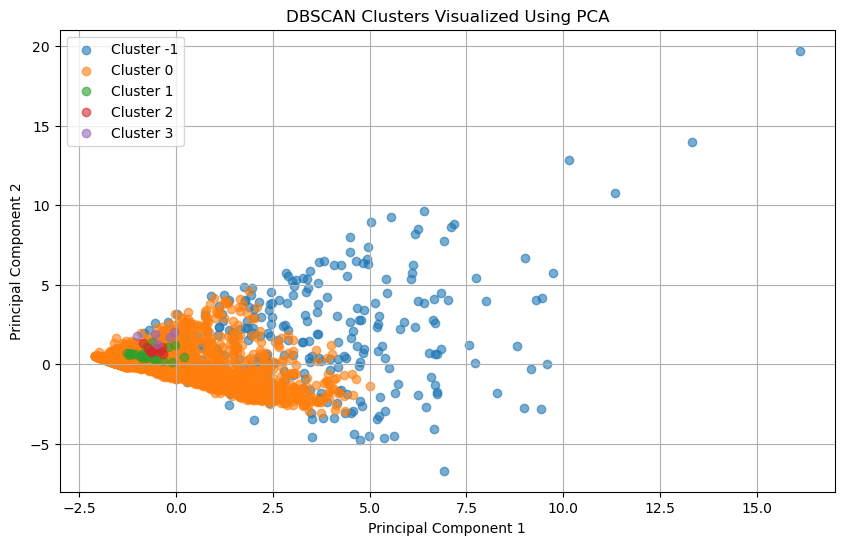

In [39]:
plt.figure(figsize=(10, 6))
for cluster in sorted(dbscan_pca_df["Cluster"].unique()):
    cluster_data = dbscan_pca_df[
        dbscan_pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clusters Visualized Using PCA")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# DBSCAN identified several density-based customer segments along with a group of noise observations. The noise points represent customers whose behavior does not belong to a sufficiently dense region. Unlike K-Means, DBSCAN can identify such observations without forcing every customer into a cluster.

In [40]:
#DBSCAN cluster profiling
dbscan_clustered_df = df.copy()
dbscan_clustered_df["Cluster"] = dbscan_labels
dbscan_profile = dbscan_clustered_df.groupby("Cluster").mean()
dbscan_profile.round(2)

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
Cluster,,,,,,,,,,
-1,227232.51,1449.06,2.81,1.06,1.19,49706.21,25.77,3412.41,9.87,4856.37
0,63258.20,46.84,2.02,1.00,1.00,14958.21,10.61,258.79,0.79,4071.42
1,39212.59,0.00,1.00,2.00,1.00,8790.09,13.36,120.45,0.50,3779.18
2,30501.10,0.00,1.00,3.00,1.00,14904.90,15.00,40.00,0.20,3753.00
3,78724.80,6071.40,1.00,1.00,1.00,5028.80,4.20,183.40,0.80,3351.40


In [41]:
dbscan_cluster_counts = (
    pd.Series(dbscan_labels)
    .value_counts()
    .sort_index()
)

print(dbscan_cluster_counts)

-1     257
 0    3705
 1      22
 2      10
 3       5
Name: count, dtype: int64


In [42]:
noise_count = np.sum(dbscan_labels == -1)
noise_percentage = (noise_count / len(dbscan_labels)) * 100
print("Noise Count:", noise_count)
print("Noise Percentage:", round(noise_percentage, 2), "%")

Noise Count: 257
Noise Percentage: 6.43 %


In [43]:
# DBSCAN achieved a higher Silhouette Score (0.6255) compared with K-Means (0.3583), indicating better cluster cohesion and separation for this dataset. Additionally, DBSCAN identified 257 observations as noise, which K-Means cannot do explicitly. Therefore, DBSCAN provided a more suitable clustering solution for this dataset under the selected parameters.

In [ ]:
# Conclusion:

# Clustering techniques were applied to segment airline customers based on their travel activity, mileage, transactions, account balance, and enrollment characteristics. The data was cleaned, explored, standardized, and analyzed using visualization and correlation techniques. K-Means clustering was evaluated using the Elbow Method and Silhouette Score, with K=2 selected as the final solution and a Silhouette Score of 0.3583. DBSCAN was then implemented using eps=1.5 and min_samples=5, achieving a higher Silhouette Score of 0.6255. DBSCAN identified four clusters and 257 noise observations, demonstrating its ability to detect potentially unusual customer behavior. Overall, DBSCAN provided better cluster separation for this dataset according to the Silhouette Score and offered additional benefits through noise detection.